In [1]:
import pandas as pd

df=pd.read_csv("netflix_cleaned.csv")
print(df['Country'].isnull().sum())
###  Clean Country information
df=df.dropna(subset=['Country'])
df["Country"]=df["Country"].str.split(", ")
df=df.explode("Country")
df["Country"]=df["Country"].str.strip()
print(df)
print(df["Country"])


0
     Show ID     Type                             Title         Director  \
0         s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1         s3  TV Show                         Ganglands  Julien Leclercq   
2         s6  TV Show                     Midnight Mass    Mike Flanagan   
3        s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4         s8    Movie                           Sankofa     Haile Gerima   
...      ...      ...                               ...              ...   
8785   s8797  TV Show                        Yunus Emre          Unknown   
8786   s8798  TV Show                         Zak Storm          Unknown   
8787   s8801  TV Show                Zindagi Gulzar Hai          Unknown   
8788   s8784  TV Show                              Yoko          Unknown   
8789   s8786  TV Show                               YOM          Unknown   

            Country  Date Added  Release Year Rating   Duration  \
0     United State

In [2]:
### Calculate Content Count by Country
count_countries=df.groupby("Country").size().reset_index(name="Count_titles")
count_countries=count_countries.sort_values("Count_titles", ascending=False)
print(count_countries)


           Country  Count_titles
79   United States          3240
29           India          1057
78  United Kingdom           638
51        Pakistan           421
80         Unknown           287
..             ...           ...
61         Senegal             1
57     Puerto Rico             1
65         Somalia             1
84    West Germany             1
85        Zimbabwe             1

[86 rows x 2 columns]


In [3]:
### Top Content Producings Countries
top10=count_countries.head(10)
print(top10)

           Country  Count_titles
79   United States          3240
29           India          1057
78  United Kingdom           638
51        Pakistan           421
80         Unknown           287
10          Canada           271
36           Japan           259
67     South Korea           214
20          France           213
69           Spain           182


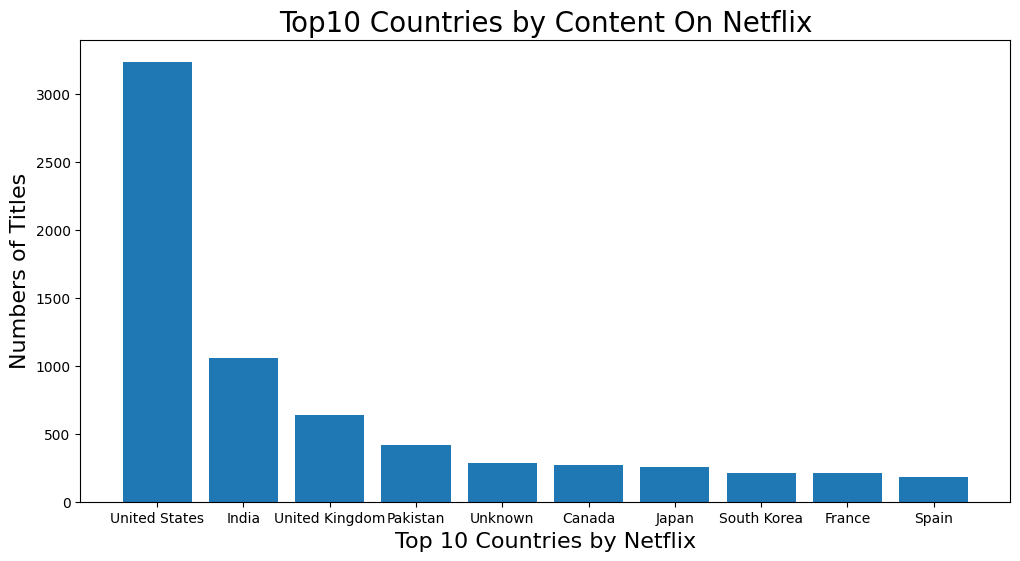

In [4]:
###  Chart and rankings
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar(top10["Country"], top10["Count_titles"])
plt.title("Top10 Countries by Content On Netflix", size=20)
plt.xlabel("Top 10 Countries by Netflix", size=16)
plt.ylabel("Numbers of Titles", size=16)
# plt.gca().invert_yaxis()
plt.show()


In [5]:
total=count_countries["Count_titles"].sum()
top5_sum=count_countries.head(5)["Count_titles"].sum()
top5_percentage=(top5_sum/total)*100
print(f"Top 5 countries make up {top5_percentage:.1f}% of total.")

Top 5 countries make up 64.2% of total.


## Task 3: Country-Wise Netflix Content Analysis — Summary

| Metric | Value |
|---|---|
| Top Country | United States — 3,240 titles |
| 2nd Highest | India — 1,057 titles |
| 3rd Highest | United Kingdom — 538 titles |
| Top 5 Countries Share | 64.2% of total content |
| Remaining 81 Countries | 35.8% of total content |
| Unknown/Unlabeled | 287 titles |

### Conclusion
Netflix's content library is heavily concentrated in the United States, which holds nearly 3x the volume of the next-highest country (India). This points to a US-first content strategy rather than balanced global investment. The remaining 81 countries collectively account for just over a third of total titles, showing that while Netflix has a broad international footprint, content depth outside the top markets remains comparatively thin. 287 titles had no country data recorded, which is a data quality gap worth noting.